In [1]:
"""""""""""""""""
Required packages
"""""""""""""""""
import math
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme() 

# <font color=darkcyan>Modèles de mélange</font>

## <font color=darkorange>Densité de mélange </font>

Considérons un mélange de $K$ lois dont la densité est donnée par
$$f(x, \theta)=\sum_{k=1}^K\pi_kf(x, \theta_k),$$
où $0<\pi_k<1$, $\sum_{k=1}^K\pi_k=1$, $\theta = (\theta_1, \ldots, \theta_K)$. 

Dans l'optique du calcul de l'estimateur de maximum de vraisemblance, nous désirons calculer la logdensité du mélange, à partir des logdensités des composantes du mélange. 

#### Question 1
Ecrire une fonction `mixture_logpdf` qui prend en argument une liste de logdensités et une liste de poids et renvoie la logdensité du mélange associé.

In [8]:
def mixture_logpdf(log_probs, weights):
    def logp(x):
        log_marginal = np.array([log_probs[i](x) for i in range(len(log_probs))])
        w = np.reshape(weights, [-1] + [1]*len(log_marginal.shape[1:]))
        return np.log((w*np.exp(log_marginal)).sum(axis=0))
    return logp

### Mélange de gaussiennes multivariées

Considérons un mélange de $K$ lois gaussiennes multivariées dont la densité est donnée par
$$f_\theta(x)=\sum_{k=1}^K\pi_kf_{\mathcal N(\mu_k,\Sigma_k)}(x),$$
où $0<\pi_k<1$, $\sum_{k=1}^K\pi_k=1$, $\mu_k\in\mathbb R^d$ et $\Sigma_k \in \mathcal{M}_d(\mathbb R)$ semi-definie positive, $k=1,\dots,K$. 

#### Question 2
Ecrire une fonction `multi_gauss_logpdf` qui prend en argument une moyenne et une matrice de covariance et renvoie la logdensité gaussienne associée à ces paramètres. On écrira une fonction pour une variable en dimension $d>1$. On rappelle que

$$f_{\mathcal N(\mu,\Sigma)}(x) = \frac {1}{(2\pi )^{d/2} \det(\Sigma )^{1/2}}\;\;e^{-{\frac {1}{2}}(x-\mu )^{\top }\Sigma ^{-1}(x-\mu )} \quad \forall x\in\mathbb R ^d$$

In [23]:
def multi_gauss_logpdf(m, Sig):
    det = np.linalg.det(Sig)
    if(det == 0):
        raise ValueError("Covariance matrix is singular.")
    d = len(m)
    Siginv = np.linalg.inv(Sig)
    def f(x):
        diff = x-m
        quad = np.sum(diff @ Siginv * diff, axis=1)
        return np.log(1/((2*np.pi)**(d/2)*np.sqrt(det)) * np.exp(-0.5 * quad))
    return f

#### Question 3
Utilisez la fonction `mixture_logpdf` pour tracer la densité d'un mélange de trois gaussiennes en dimension 2, de paramètres

\begin{equation*}
\mu_1 = \binom 2  2, 
\Sigma_1 = 
\begin{pmatrix}
1. & 0.5 \\
0.5 & 1.
\end{pmatrix}, \quad
\mu_2 = -\mu_1, 
\Sigma_2 = 
\begin{pmatrix}
1. & -0.1 \\
-0.1 & 1.
\end{pmatrix}, \quad
\mu_3 = \binom{-1.5 }{ 2.2}, 
\Sigma_3 = 
\begin{pmatrix}
0.8 & 0 \\
0 & 0.8
\end{pmatrix}
\end{equation*}

Les mélanges de lois gaussiennes peuvent être implémentés directement en Python en utilisant le package `sklearn.mixture`, voir ici https://scikit-learn.org/stable/modules/mixture.html pour une aide détaillée (non nécessaire pour cette question).


In [83]:
def plot_surf(U, V, Z, figsize=(15, 12)):
    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(projection='3d'))
    ax.view_init(40, 50)
    plt.rcParams['axes.grid'] = False
    surf = ax.plot_surface(U, V, Z, rstride=1, cstride=1, cmap="coolwarm", linewidth=0)
    ax.contourf(U, V, Z, zdir='z', offset=Z.max()+3, cmap="coolwarm", alpha=0.5)
    ax.set_zlim(top=Z.max()+15)
    fig.colorbar(surf)
    ax.set_xlabel('u')
    ax.set_ylabel('v')
    ax.set_zlabel('z')
    plt.rcParams['axes.grid'] = True
    return fig, ax

(250000, 2)


(<Figure size 1500x1200 with 2 Axes>,
 <Axes3D: xlabel='u', ylabel='v', zlabel='z'>)

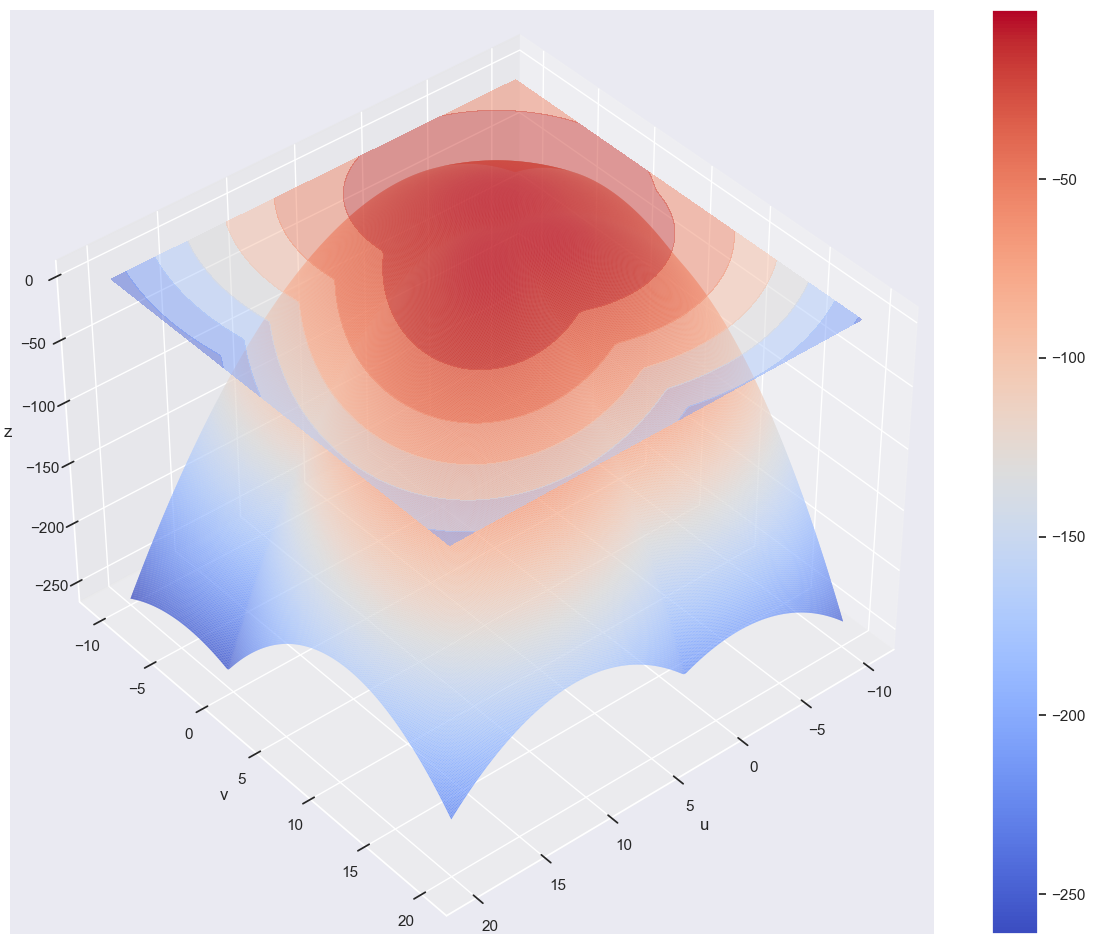

In [85]:
a = multi_gauss_logpdf(np.array([2,2]), np.array([[1,0.5],[0.5,1]]))
b = multi_gauss_logpdf(np.array([-2,-2]), np.array([[1,-0.1],[-0.1,1]]))
c = multi_gauss_logpdf(np.array([-1.5,2.2]), np.array([[0.8,0],[0,0.8]]))

M = mixture_logpdf(np.array([a,b,c]), 1/3 * np.ones(3))

x = np.linspace(-10,20,500)
y = np.linspace(-10,20,500)
X, Y = np.meshgrid(x,y)

xr = X.ravel()
yr = Y.ravel()
dom = np.column_stack([xr,yr])
print(dom.shape)

den = M(dom)
den = den.reshape(X.shape)

plot_surf(X, Y, den)

## Mélange de lois uniformes
Considérons les mélanges de lois uniformes $U_k \sim \mathcal U([0,\lambda_k])$, $k=1,\ldots,K$, dont la densité est donnée par 
$$f_\theta(x)=\sum_{k=1}^K\pi_kf_{U_k}(x),$$
où $0<\pi_k<1$, $\sum_{k=1}^K\pi_k=1$ et $\lambda_k>0$, $k=1,\dots,K$.

#### Question 4
- Écrire une fonction `uniform_logpdf` qui prend en argument un paramètre $\lambda$ et renvoie la logdensité de la loi uniforme $U\sim\mathcal U([0,\lambda])$. 

- Quelles formes de densité peut-on obtenir avec un mélange de lois uniformes ?

- Afficher dans un même graphe la densité du mélange uniforme de paramètres $(\lambda_1, \lambda_2, \lambda_3) = (2,7,15)$ et de poids $(w_1, w_2, w_3) = (0.15, 0.40,0.45)$, ainsi que les densités de chacune de ses composantes.


In [96]:
def uniform_logpdf(l):
    #on va obtenir que la densité est constante avec valeur -log(lambda) entre [0,lambda]
    def f(x):
        x = np.asarray(x)
        y = -np.inf*np.ones(len(x))
        i = (0<x) & (x<l)
        y[i] = -np.log(l)
        return y
    return f

C:\Users\polti\AppData\Local\Temp\ipykernel_14164\3386767522.py:5: RuntimeWarning: divide by zero encountered in log
  return np.log((w*np.exp(log_marginal)).sum(axis=0))


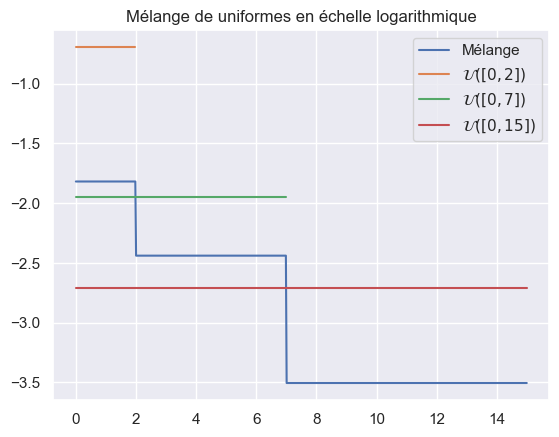

In [136]:
a = uniform_logpdf(2)
b = uniform_logpdf(7)
c = uniform_logpdf(15)

w = [0.15, 0.4, 0.45]

M = mixture_logpdf([a,b,c], w)
X = np.linspace(-5,20,1000)


fig, ax = plt.subplots()
ax.set_title("Mélange de uniformes en échelle logarithmique")
ax.plot(X, M(X), label="Mélange")
ax.plot(X, a(X), label="$\\mathcal{U}([0,2])$")
ax.plot(X, b(X), label="$\\mathcal{U}([0,7])$")
ax.plot(X, c(X), label="$\\mathcal{U}([0,15])$")
ax.legend()
plt.show()

## Mélange de lois Gamma

Considérons les mélanges de loi Gamma $\Gamma(\alpha,\beta)$ dont la densité est donnée par 
$$f_\theta(x)=\sum_{k=1}^K\pi_kf_{\Gamma(\alpha_k,\beta_k)}(x),$$
où $0<\pi_k<1$, $\sum_{k=1}^K\pi_k=1$ et $\alpha_k>0, \beta_k>0$ pour $k=1,\dots,K$. 

#### Question 5
- Écrire une fonction `gamma_logpdf` qui prend en argument deux paramètres $a$ et $b$ et renvoie la logdensité de la loi $\Gamma(a,b)$. 

- Quelles formes de densité peut-on obtenir avec un mélange de lois Gamma ? 


- Afficher dans un même graphe la densité du mélange de lois Gamma de paramètres $a = (2.0,4.0,30.0)$ et $
b = (1.0,0.5,2.5)$ et de poids $(w_1, w_2, w_3) = (0.15, 0.40,0.45)$, ainsi que les densités de chacune de ses composantes.

- Comparer aux formes des mélanges gaussiens.

In [132]:
import scipy

def gamma_logpdf(a,b):
    G = b**a / scipy.special.gamma(a)
    def f(x):
        x = np.asarray(x)
        y = np.full_like(x,-np.inf)
        dom = (x>0)
        y[dom] = np.log(G) + (a-1)*np.log(x[dom]) + (-x[dom]*b)
        return y
    return f

C:\Users\polti\AppData\Local\Temp\ipykernel_14164\3386767522.py:5: RuntimeWarning: divide by zero encountered in log
  return np.log((w*np.exp(log_marginal)).sum(axis=0))


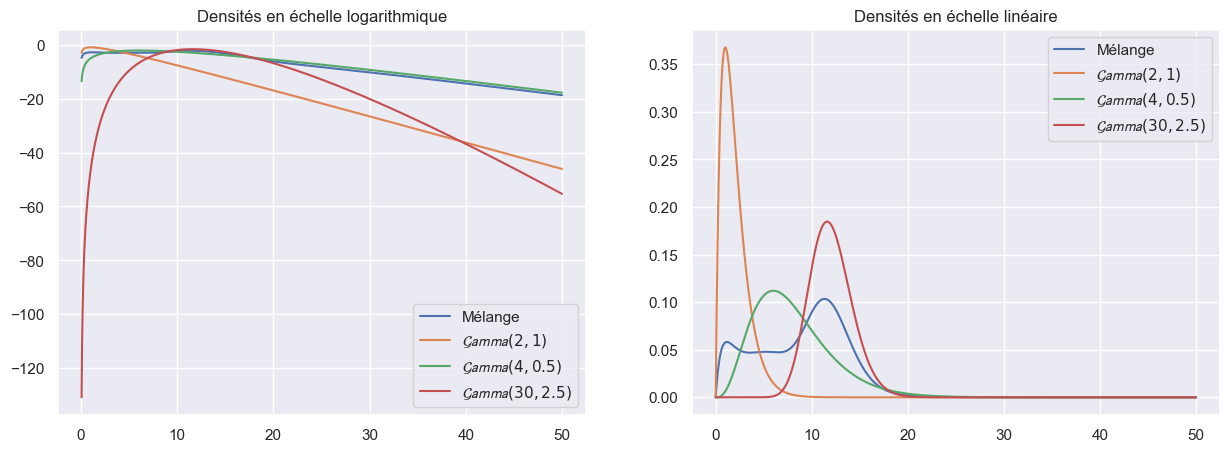

In [135]:
a = gamma_logpdf(2,1)
b = gamma_logpdf(4,0.5)
c = gamma_logpdf(30,2.5)

w = np.array([0.15, 0.4, 0.45])

X = np.linspace(0,50,1000)
M = mixture_logpdf(np.array([a,b,c]), w)

fig, ax = plt.subplots(1,2, figsize=(15,5))
ax[0].set_title("Densités en échelle logarithmique")
ax[1].set_title("Densités en échelle linéaire")
ax[0].plot(X, M(X),label="Mélange")
ax[0].plot(X, a(X),label="$\\mathcal{Gamma}(2,1)$")
ax[0].plot(X, b(X),label="$\\mathcal{Gamma}(4,0.5)$")
ax[0].plot(X, c(X),label="$\\mathcal{Gamma}(30,2.5)$")
ax[0].legend()
ax[1].plot(X, np.exp(M(X)),label="Mélange")
ax[1].plot(X, np.exp(a(X)),label="$\\mathcal{Gamma}(2,1)$")
ax[1].plot(X, np.exp(b(X)),label="$\\mathcal{Gamma}(4,0.5)$")
ax[1].plot(X, np.exp(c(X)),label="$\\mathcal{Gamma}(30,2.5)$")
ax[1].legend()
plt.show()


## <font color=darkorange>Simulation de données</font>

#### Question 5
- Ecrire une fonction `gaussian_mixture` pour générer des réalisations d'un mélange gaussien à $K$ composantes. Les arguments de la fonction sont la taille d'échantillon `n`, le moyennes `mu`, variances `sigma` et poids des éléments du mélange `weights`.
- Tester votre fonction en générant un grand échantillon d'un mélange gaussien de taille `n=5000` dont on compare l'histogramme à sa densité par un graphique.

In [ ]:
def gaussian_mixture(n, mu, sigma, weights):
    

## <font color=darkorange>Estimation du modèle</font>

#### Question 6
- Estimez les paramètres du modèle en utilisant les échantillons précédents et le package `mixture` de `sklearn`. On pourra utiliser la classe `GaussianMixture` et la méthode `fit`.
- Fournissez les paramètres estimés (à l'aide des attributs `means_`, `weights_`, etc.).